In [50]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [51]:
df = pd.read_csv("olympics_medalists.csv")
df.head()

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   medalist_name                 1875 non-null   object
 1   male_archery                  11 non-null     object
 2   female_archery                9 non-null      object
 3   male_athletics                85 non-null     object
 4   female_athletics              81 non-null     object
 5   male_badminton                12 non-null     object
 6   female_badminton              10 non-null     object
 7   male_baseball                 72 non-null     object
 8   male_basketball               35 non-null     object
 9   female_basketball             36 non-null     object
 10  male_boxing                   44 non-null     object
 11  male_canoeing and kayaking    53 non-null     object
 12  female_canoeing and kayaking  21 non-null     object
 13  male_road bicycle 

Index(['medalist_name', 'male_archery', 'female_archery', 'male_athletics',
       'female_athletics', 'male_badminton', 'female_badminton',
       'male_baseball', 'male_basketball', 'female_basketball', 'male_boxing',
       'male_canoeing and kayaking', 'female_canoeing and kayaking',
       'male_road bicycle racing', 'female_road bicycle racing',
       'male_track cycling', 'female_track cycling', 'male_mountain biking',
       'female_mountain biking', 'male_bmx', 'female_bmx', 'male_diving',
       'female_diving', 'female_equestrian sport', 'male_equestrian sport',
       'male_fencing', 'female_fencing', 'male_field hockey',
       'female_field hockey', 'male_association football',
       'female_association football', 'male_artistic gymnastics',
       'female_artistic gymnastics', 'female_rhythmic gymnastics',
       'male_trampoline gymnastics', 'female_trampoline gymnastics',
       'male_handball', 'female_handball', 'male_judo', 'female_judo',
       'male_modern penta

In [53]:
tidy_df= df.melt(
    id_vars=["medalist_name"],
    var_name= "gender_sport",
    value_name = "medal"
)

tidy_df = tidy_df.dropna(subset= ['medal'])

In [54]:
tidy_df[['gender','sport']]= tidy_df['gender_sport'].str.split('_', n=1, expand=True)

tidy_df['sport'] = tidy_df ['sport'].str.strip()
tidy_df = tidy_df.drop(columns=['gender_sport'])

print (tidy_df.head())

      medalist_name   medal gender    sport
177    Bair Badënov  bronze   male  archery
676   Ilario Di Buò  silver   male  archery
682    Im Dong-hyun    gold   male  archery
760       Jiang Lin  bronze   male  archery
920  Lee Chang-hwan    gold   male  archery


In [55]:
pivot_summary = tidy_df.pivot_table(index='gender', columns='medal', values = 'medalist_name', aggfunc= 'count')
print(pivot_summary)

medal   bronze  gold  silver
gender                      
female     294   271     278
male       374   315     343


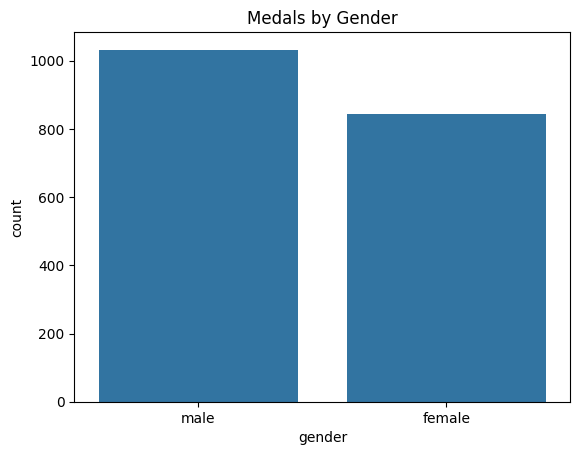

In [56]:
sns.countplot(data=tidy_df, x='gender')
plt.title('Medals by Gender')
plt.show()

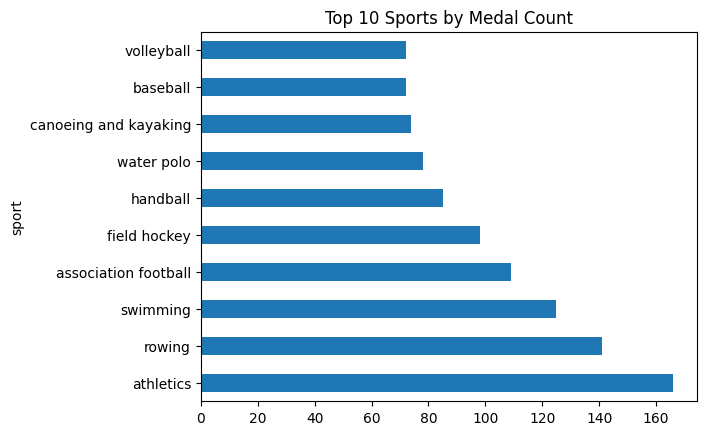

In [58]:
top_10=tidy_df['sport'].value_counts().nlargest(10)
top_10.plot(kind='barh')
plt.title('Top 10 Sports by Medal Count')
plt.show()